In [70]:
import seaborn as sns

import pyarrow.dataset as ds
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem,Draw


from smiles_blocks.files import INTERIM_DATA_DIR,FIGURES_DIR
from smiles_blocks.smiles_fragmentation import ExtendedRoThreeThreshold
from IPython.display import SVG

In [36]:
fig_dir=FIGURES_DIR / "fragmentation_results"
fig_dir.mkdir(exist_ok=True, parents=True)

In [37]:
well_sampled_block_data= ds.dataset(INTERIM_DATA_DIR / "well_sampled/block_library/", format="parquet")
well_sampled_blocked_smiles_data = ds.dataset(INTERIM_DATA_DIR / "well_sampled/blocked_smiles/", format="parquet")
moses_block_data = ds.dataset(INTERIM_DATA_DIR / "moses_canonical_control/block_library/", format="parquet")
moses_blocked_smiles_data = ds.dataset(INTERIM_DATA_DIR / "moses_canonical_control/blocked_smiles/", format="parquet")

In [38]:
well_sample_blocked_df = well_sampled_blocked_smiles_data.to_table().to_pandas()
moses_blocked_df = moses_blocked_smiles_data.to_table().to_pandas()

In [39]:
well_sample_blocked_df["nb_blocks"]= [blocked_smiles.count(".")+1 for blocked_smiles in well_sample_blocked_df["smiles_blocked"]]

In [40]:
well_sample_blocked_df["retrosynthetic_success"].value_counts(normalize=True)

retrosynthetic_success
True     0.995815
False    0.004185
Name: proportion, dtype: float64

In [41]:
well_sample_blocked_df["fragmentation_success"].value_counts(normalize=True)

fragmentation_success
True     0.995815
False    0.004185
Name: proportion, dtype: float64

In [42]:
well_sample_blocked_df.shape

(1936962, 10)

In [43]:
well_sampled_successful_fragmentation_results = well_sample_blocked_df[well_sample_blocked_df["fragmentation_success"] == True]

In [44]:
well_sampled_successful_fragmentation_results["retro_bond_ratio"].describe()

count    1.928855e+06
mean     9.696075e-01
std      7.748662e-02
min      2.857143e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: retro_bond_ratio, dtype: float64

In [45]:
# 5% quantile edges (demi-deciles) for retro_bond_ratio
demi_decile_edges = well_sampled_successful_fragmentation_results["retro_bond_ratio"].quantile(
    [i / 20 for i in range(21)]
)
print(demi_decile_edges)

0.00    0.285714
0.05    0.800000
0.10    0.833333
0.15    1.000000
0.20    1.000000
0.25    1.000000
0.30    1.000000
0.35    1.000000
0.40    1.000000
0.45    1.000000
0.50    1.000000
0.55    1.000000
0.60    1.000000
0.65    1.000000
0.70    1.000000
0.75    1.000000
0.80    1.000000
0.85    1.000000
0.90    1.000000
0.95    1.000000
1.00    1.000000
Name: retro_bond_ratio, dtype: float64


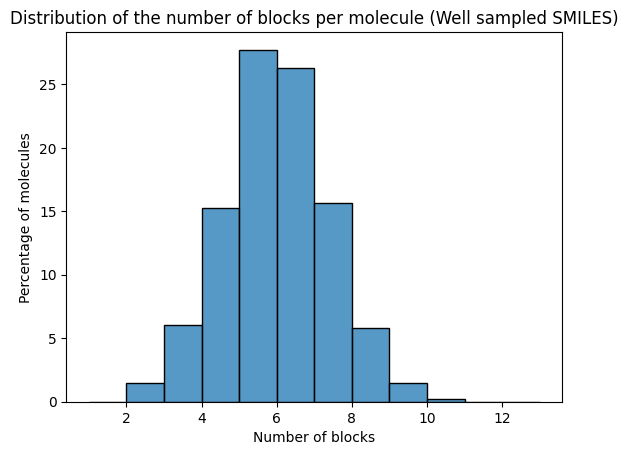

<Figure size 640x480 with 0 Axes>

In [46]:
fig = sns.histplot(
    data=well_sampled_successful_fragmentation_results,
    x="nb_blocks",
    bins=range(1, well_sampled_successful_fragmentation_results["nb_blocks"].max() + 2),
    stat="percent",
)
fig.set_title("Distribution of the number of blocks per molecule (Well sampled SMILES)")
fig.set_xlabel("Number of blocks")
fig.set_ylabel("Percentage of molecules")
fig.patch.set_alpha(0)
plt.savefig(fig_dir / "nb_blocks_distribution.svg", transparent=True)
plt.show()
plt.clf()

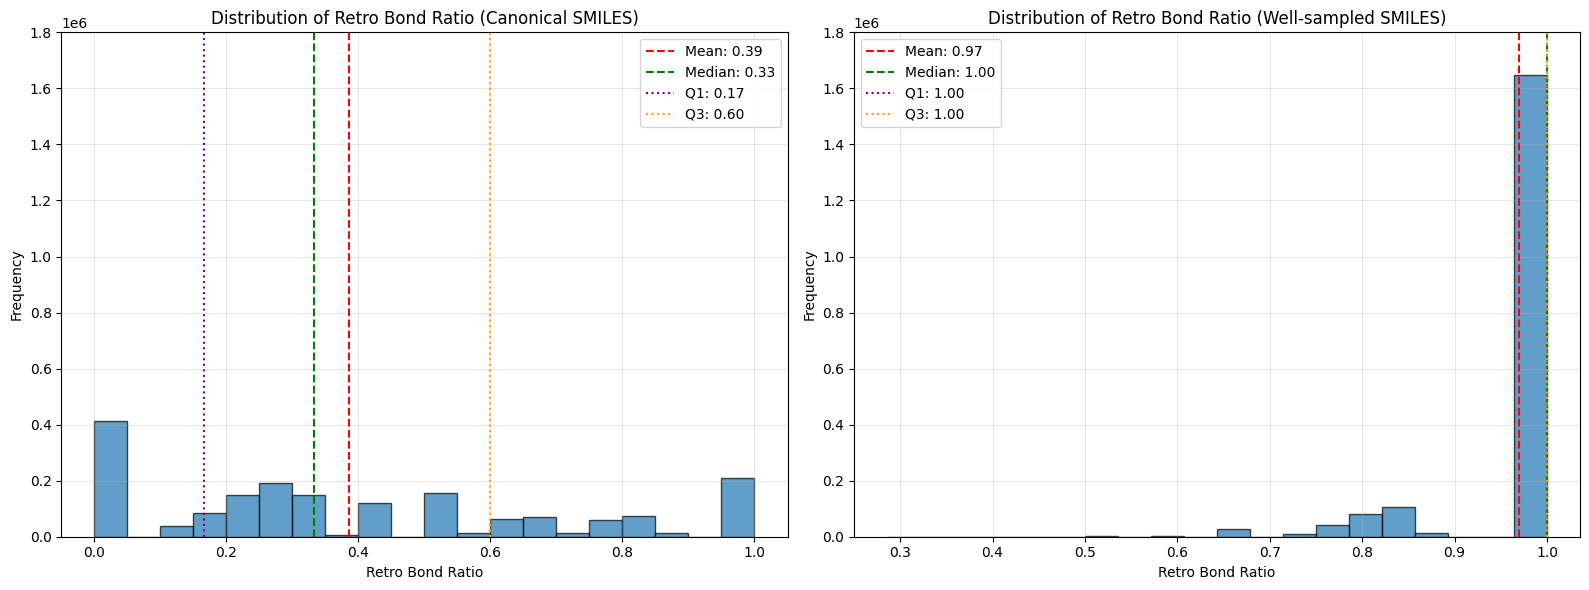

<Figure size 640x480 with 0 Axes>

In [47]:
# Combine the dataframes for analysis
df_can = moses_blocked_df.query("retro_bond_ratio >= 0.0").copy()
df_well = well_sample_blocked_df.query("retro_bond_ratio >= 0.0").copy()

# Add source column to identify the dataset
df_can['source'] = 'Canonical SMILES'
df_well['source'] = 'Well-sampled SMILES'

# Combine the dataframes
combined_df = pd.concat([df_can, df_well], ignore_index=True)

# Create figure for comparing distributions with transparent background
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='none')
fig.patch.set_alpha(0)  # Make figure background transparent

# Plot histograms for both datasets
for i, source in enumerate(['Canonical SMILES', 'Well-sampled SMILES']):
    subset = combined_df[combined_df['source'] == source]
    
    # Plot histogram
    axes[i].hist(subset['retro_bond_ratio'], bins=20, alpha=0.7, edgecolor='black')
    
    # Add statistics lines
    mean_val = subset['retro_bond_ratio'].mean()
    median_val = subset['retro_bond_ratio'].median()
    q1 = subset['retro_bond_ratio'].quantile(0.25)
    q3 = subset['retro_bond_ratio'].quantile(0.75)
    
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    axes[i].axvline(q1, color='purple', linestyle=':', label=f'Q1: {q1:.2f}')
    axes[i].axvline(q3, color='orange', linestyle=':', label=f'Q3: {q3:.2f}')
    
    # Set labels, title, and y-axis limit
    axes[i].set_xlabel('Retro Bond Ratio')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Distribution of Retro Bond Ratio ({source})')
    axes[i].set_ylim(0, 1_800_000)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].patch.set_alpha(0)  # Make subplot background transparent

# Add overall title and adjust layout
plt.tight_layout()
plt.savefig(fig_dir / "retro_bond_ratio_distribution_comparison.svg")
plt.show()
plt.clf()

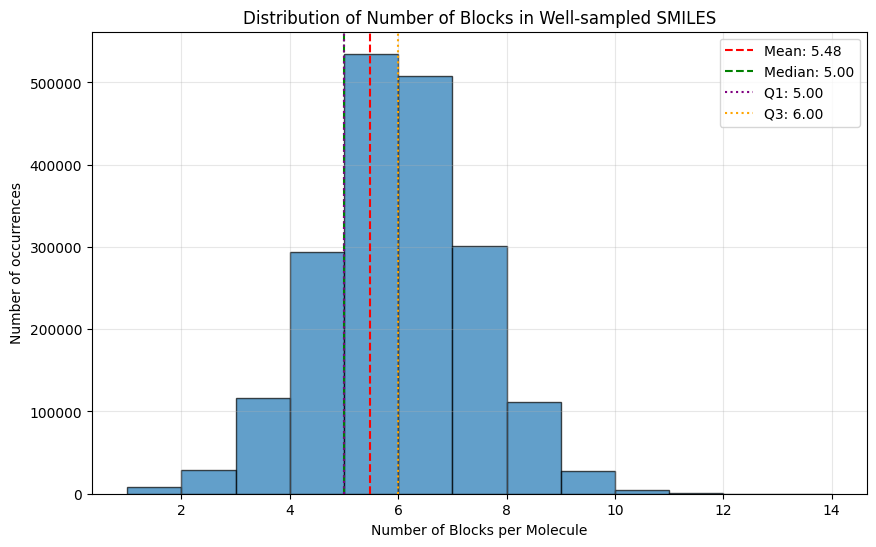

In [48]:
plt.figure(figsize=(10, 6))
plt.hist(well_sample_blocked_df["nb_blocks"], bins=range(1, 15), edgecolor='black', alpha=0.7)

# Add vertical line for mean and median
mean_val = well_sample_blocked_df['nb_blocks'].mean()
median_val = well_sample_blocked_df['nb_blocks'].median()
q1 = well_sample_blocked_df['nb_blocks'].quantile(0.25)
q3 = well_sample_blocked_df['nb_blocks'].quantile(0.75)

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
plt.axvline(q1, color='purple', linestyle=':', label=f'Q1: {q1:.2f}')
plt.axvline(q3, color='orange', linestyle=':', label=f'Q3: {q3:.2f}')

# Calculate value counts for text annotation
value_counts = well_sample_blocked_df['nb_blocks'].value_counts().sort_index()
total = len(well_sample_blocked_df)

plt.xlabel("Number of Blocks per Molecule")
plt.ylabel("Number of occurrences")
plt.title("Distribution of Number of Blocks in Well-sampled SMILES")
plt.legend()
plt.grid(True, alpha=0.3)

# Save the figure
plt.savefig(fig_dir/ "blocks_per_molecule_distribution.svg", transparent=True)
plt.show()

In [56]:
well_sampled_blocks_df=well_sampled_block_data.to_table().to_pandas()
well_sampled_blocks_df

,block,can_smiles,first_connected_can_idx,last_connected_can_idx,unique_id,begin_tag,end_tag,MolWt,nHDonors,nHAcceptors,nRotatableBonds,CrippenlogP,TPSA,status
0,N#C,C#N,1,0,1_C#N_0,no_tag,L30,27.010899,0,1,0,0.13978,23.790001,True
1,C1=C(-N(-C2=C-C=C-C=C-1-2)-C),Cn1ccc2ccccc21,3,2,3_Cn1ccc2ccccc21_2,L16,L14,131.073502,0,0,0,2.17830,4.930000,True
2,C,C,0,0,0_C_0,L8,L4,16.031300,0,0,0,0.63610,0.000000,True
3,S(=O)(=O),O=S=O,1,1,1_O=S=O_1,L12b,L12b,63.961899,0,2,0,-0.67020,34.139999,True
4,C1-C=C-C(-Cl)=C-C=1,Clc1ccccc1,4,5,4_Clc1ccccc1_5,L16,no_tag,112.007980,0,0,0,2.34000,0.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10612096,C1-C(=C-C=C-C=1),c1ccccc1,0,1,0_c1ccccc1_1,L16,L16,78.046951,0,0,0,1.68660,0.000000,True
10612097,O,O,0,0,0_O_0,L3,L3,18.010565,0,0,0,-0.82470,31.500000,True
10612098,C-C(=O),CC=O,0,1,0_CC=O_1,L4,L1,44.026215,0,1,0,0.20520,17.070000,True
10612099,N,N,0,0,0_N_0,L5,L5,17.026548,1,1,0,0.16200,35.000000,True


In [50]:
well_sampled_blocks_df["can_smiles"].nunique()

34310

In [53]:
ro3_dict=vars(ExtendedRoThreeThreshold())
ro3_dict

{'MolWt': 300,
 'nHDonors': 3,
 'nHAcceptors': 3,
 'nRotatableBonds': 3,
 'CrippenlogP': 3,
 'TPSA': 60}

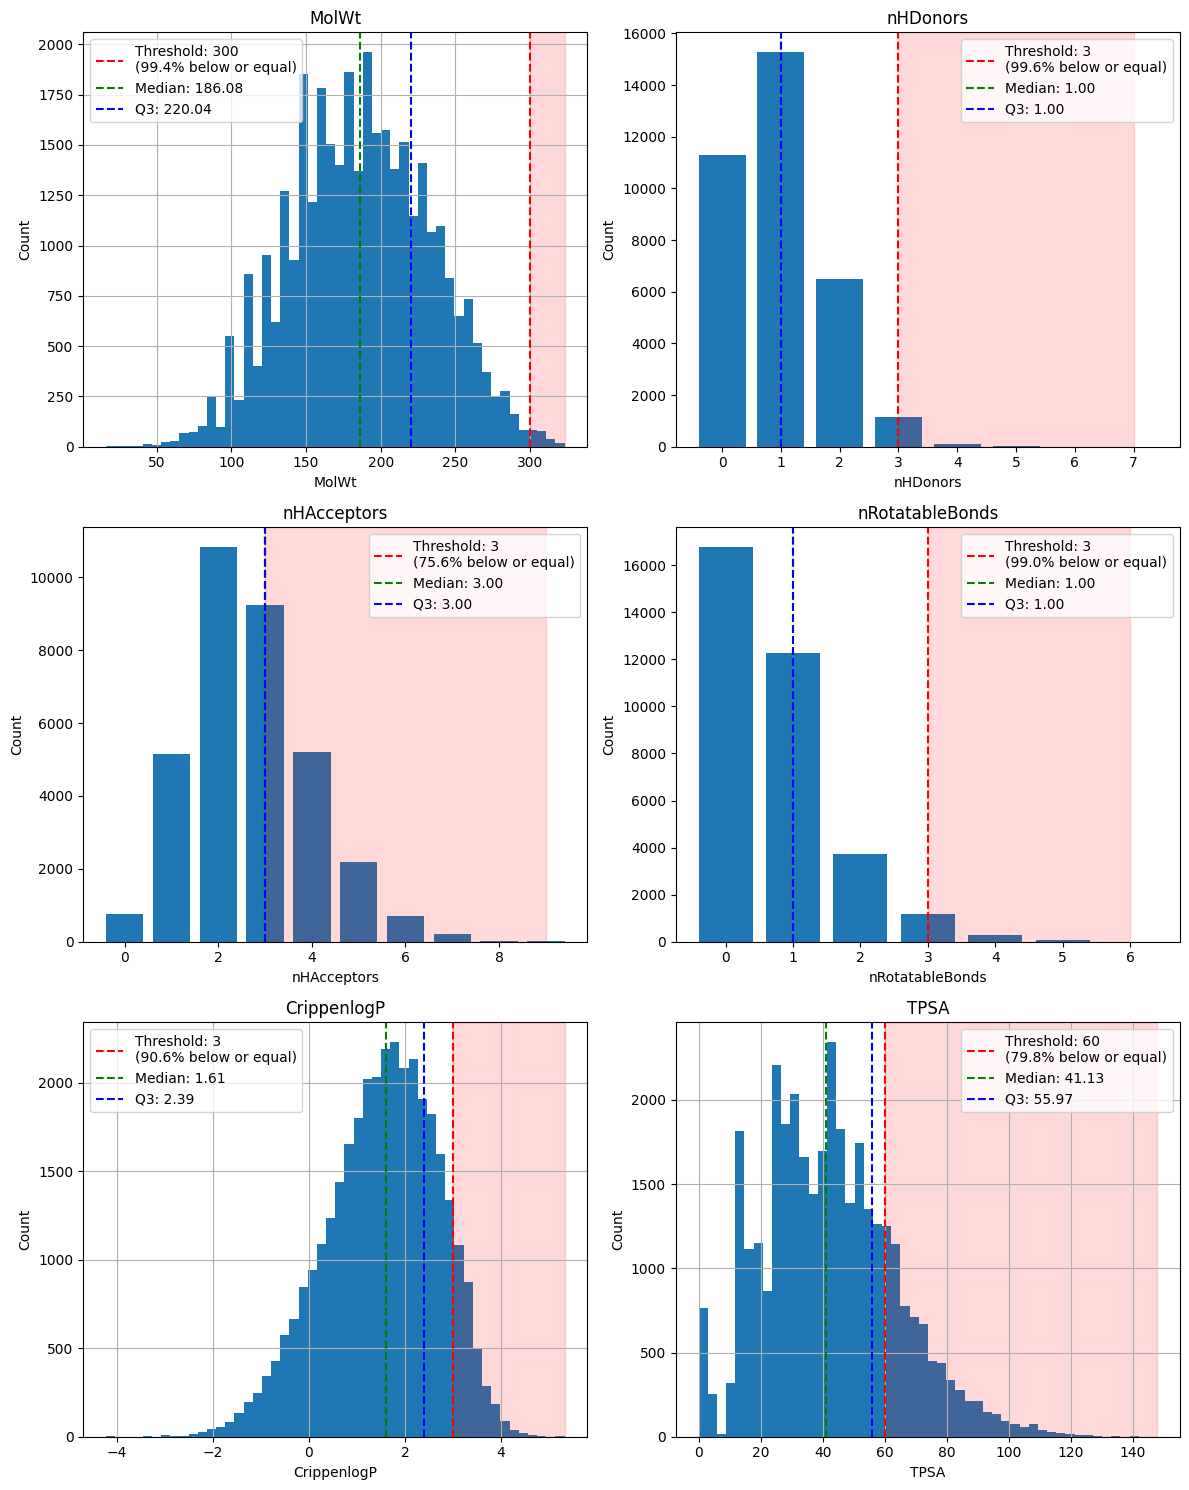

In [55]:
# Create figure with subplots - changed to 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.ravel()

# Create plots for each property
unique_blocks_df = well_sampled_blocks_df.drop_duplicates(subset=["can_smiles"])
computed_data = unique_blocks_df[ro3_dict.keys()]

for i, (prop, threshold) in enumerate(zip(ro3_dict.keys(), ro3_dict.values())):
    median = computed_data[prop].median()
    q3 = computed_data[prop].quantile(0.75)
    pct_below = (computed_data[prop] <= threshold).mean() * 100

    if  prop.startswith('n'):
        value_counts = computed_data[prop].value_counts().sort_index()
        axes[i].bar(value_counts.index, value_counts.values)
    else:
        computed_data[prop].hist(ax=axes[i], bins=50)

    # Shade region above threshold in red
    axes[i].axvspan(threshold, computed_data[prop].max(), color="red", alpha=0.15)

    axes[i].set_title(prop)
    axes[i].set_xlabel(prop)
    axes[i].set_ylabel("Count")

    axes[i].axvline(
        x=threshold, color="r", linestyle="--",
        label=f"Threshold: {threshold}\n({pct_below:.1f}% below or equal)"
    )
    axes[i].axvline(x=median, color="g", linestyle="--", label=f"Median: {median:.2f}")
    axes[i].axvline(x=q3, color="b", linestyle="--", label=f"Q3: {q3:.2f}")
    axes[i].legend()

plt.tight_layout()
plt.savefig(fig_dir / "well_sampled_blocks_properties.svg", transparent=True)
plt.show()


In [61]:
def find_failure_reason(row,  thresholds : dict = ro3_dict):
    reasons = ""
    for prop, threshold in thresholds.items():
        if row[prop] > threshold:
            reasons += f"{prop} ({row[prop]:.2f} > {threshold})\n"
    return reasons if reasons else "None"

In [64]:
unique_blocks_df = well_sampled_blocks_df.drop_duplicates(subset=["can_smiles"])
unique_blocks_df['failure_reasons'] = unique_blocks_df.apply(find_failure_reason, axis=1)
bad_blocks = unique_blocks_df[unique_blocks_df["failure_reasons"] != "None"]

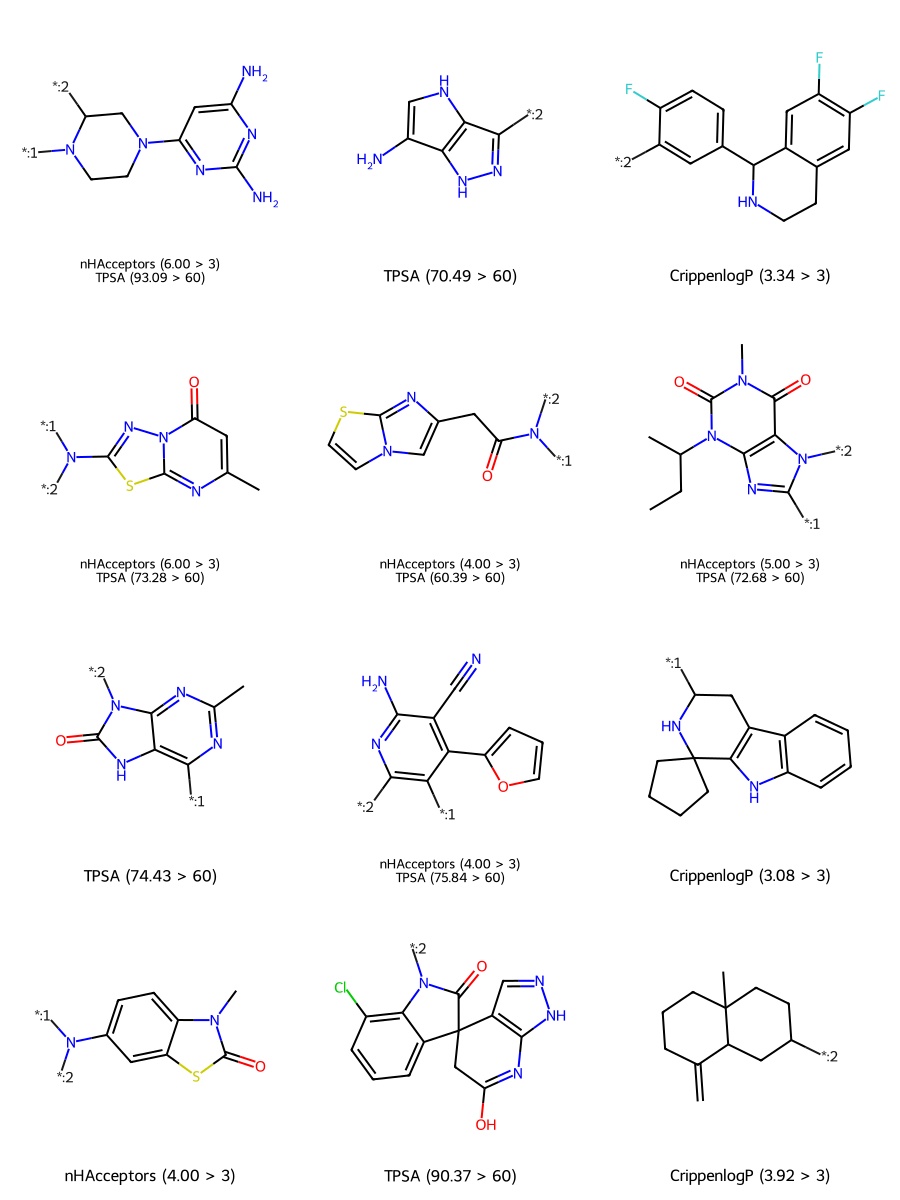

In [73]:
# Convert block SMILES to mol objects
mols = []
legends = []

block_df = bad_blocks.sample(12).reset_index(drop=True)

for _, row in block_df.iterrows():
    smiles = row["block"]
    if row["begin_tag"] != "no_tag":
        smiles = f"[*:1]{smiles}"
    if row["end_tag"] != "no_tag":
        smiles = f"{smiles}[*:2]"
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        AllChem.Compute2DCoords(mol)
        mols.append(mol)
        legends.append(row["failure_reasons"])

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    legends=legends,
    subImgSize=(300, 300),
    useSVG=True,
)

svg_path = fig_dir / "bad_blocks_sample.svg"
with open(svg_path, "w", encoding="utf-8") as f:
    f.write(img if isinstance(img, str) else img.data)

SVG(img)